# 🎨 Suite de Visualizaciones - Datos y Modelos
Gráficos bonitos para el análisis exploratorio y evaluación de modelos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix, roc_curve, auc
import json
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")
PALETTE = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#98D8C8", "#F7DC6F"]

plt.rcParams.update({
    "figure.facecolor": "#0F1419",
    "axes.facecolor": "#1a1f2e",
    "axes.edgecolor": "#2a3f5f",
    "axes.labelcolor": "#E8E8E8",
    "xtick.color": "#E8E8E8",
    "ytick.color": "#E8E8E8",
    "text.color": "#E8E8E8",
    "grid.color": "#2a3f5f",
})

print("✅ Librerías cargadas")

✅ Librerías cargadas


##  PASO 1: Cargar Dataset

In [ ]:
# Cargar datos
df = pd.read_csv("../load/dataset.csv")
print(f" Dataset cargado: {df.shape[0]:,} registros × {df.shape[1]} variables")
print(f"\n Primeras filas:")
df.head()

✅ Dataset cargado: 1,000 registros × 11 variables

📊 Primeras filas:


,edad,hora_lectura_preferida,velocidad_lectura,engagement_promedio,valence_musical_pref,energia_musical_pref,contenido_visual_pref,genero_libro_rec,tipo_vino_rec,genero_musical_rec,genero_serie_rec
0,27,manana,alta,0.85,0.51,0.69,series largas,ciencia ficcion,espumoso,electronica,ciencia ficcion
1,18,tarde,media,0.88,0.75,0.55,documentales,fantasia,afrutado,electronica,comedia
2,26,tarde,alta,0.85,0.57,0.65,documentales,fantasia,afrutado,pop,ciencia ficcion
3,32,tarde,media,0.89,0.61,0.54,peliculas,fantasia,dulce,reggaeton,ciencia ficcion
4,21,noche,alta,0.86,0.60,0.74,documentales,ciencia ficcion,seco,electronica,ciencia ficcion


##  PASO 2: Resumen General del Dataset

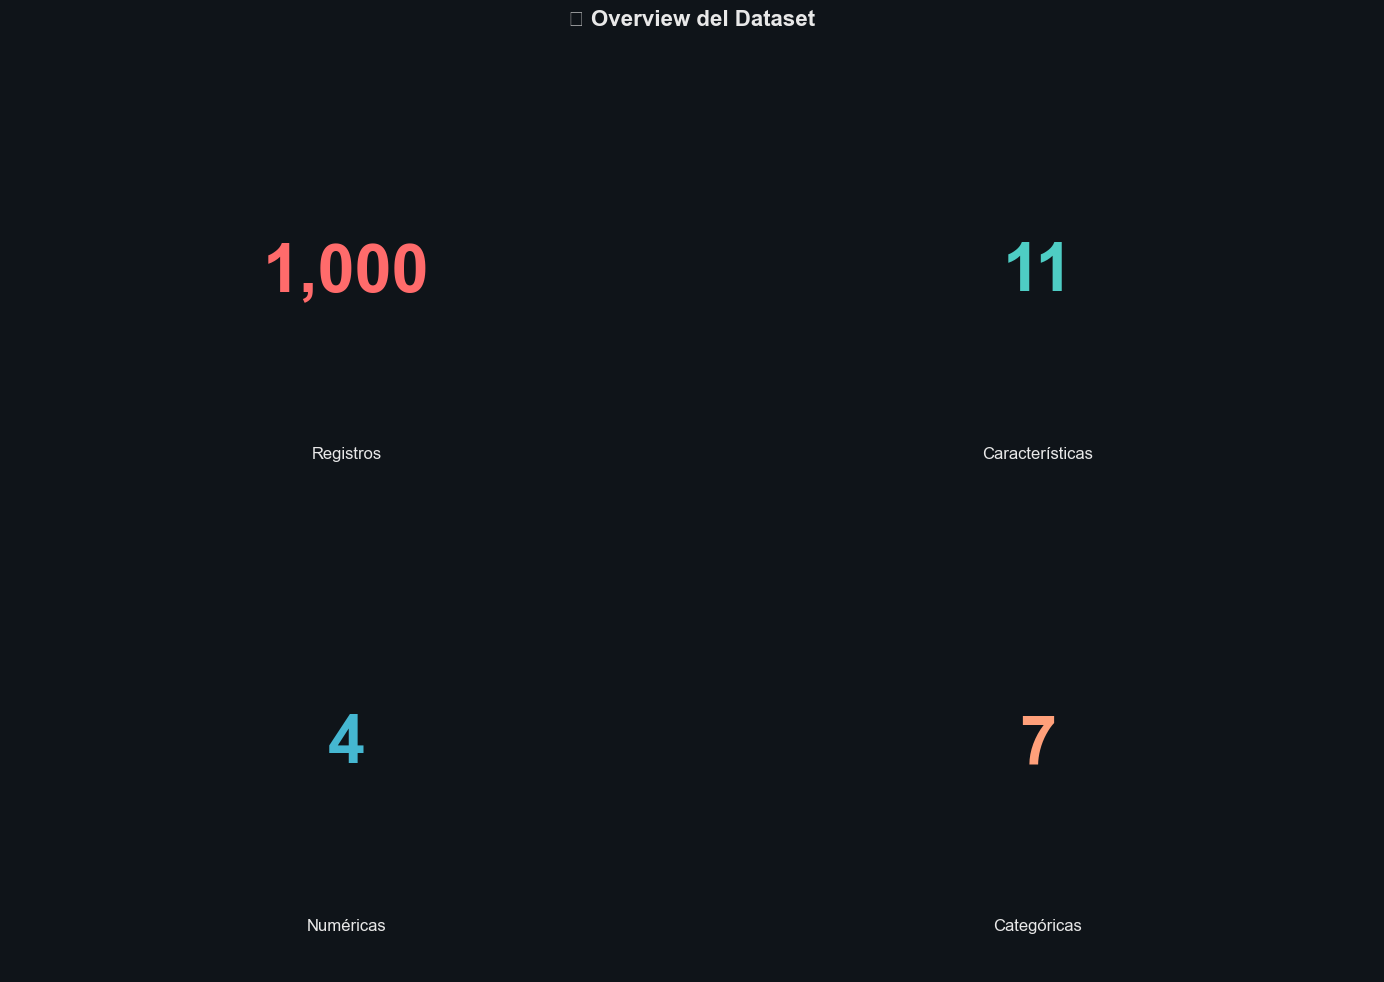

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(" Overview del Dataset", fontsize=16, fontweight="bold", y=0.98)

# Registros
ax = axes[0, 0]
ax.text(0.5, 0.5, f"{len(df):,}", ha='center', va='center',
        fontsize=48, fontweight='bold', color=PALETTE[0])
ax.text(0.5, 0.1, "Registros", ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

# Variables
ax = axes[0, 1]
ax.text(0.5, 0.5, f"{len(df.columns)}", ha='center', va='center',
        fontsize=48, fontweight='bold', color=PALETTE[1])
ax.text(0.5, 0.1, "Características", ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

# Numéricas
ax = axes[1, 0]
numeric_count = len(df.select_dtypes(include=[np.number]).columns)
ax.text(0.5, 0.5, f"{numeric_count}", ha='center', va='center',
        fontsize=48, fontweight='bold', color=PALETTE[2])
ax.text(0.5, 0.1, "Numéricas", ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

# Categóricas
ax = axes[1, 1]
categorical_count = len(df.select_dtypes(include=['object']).columns)
ax.text(0.5, 0.5, f"{categorical_count}", ha='center', va='center',
        fontsize=48, fontweight='bold', color=PALETTE[3])
ax.text(0.5, 0.1, "Categóricas", ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

plt.tight_layout()
plt.show()

##  Distribuciones - Variables Numéricas

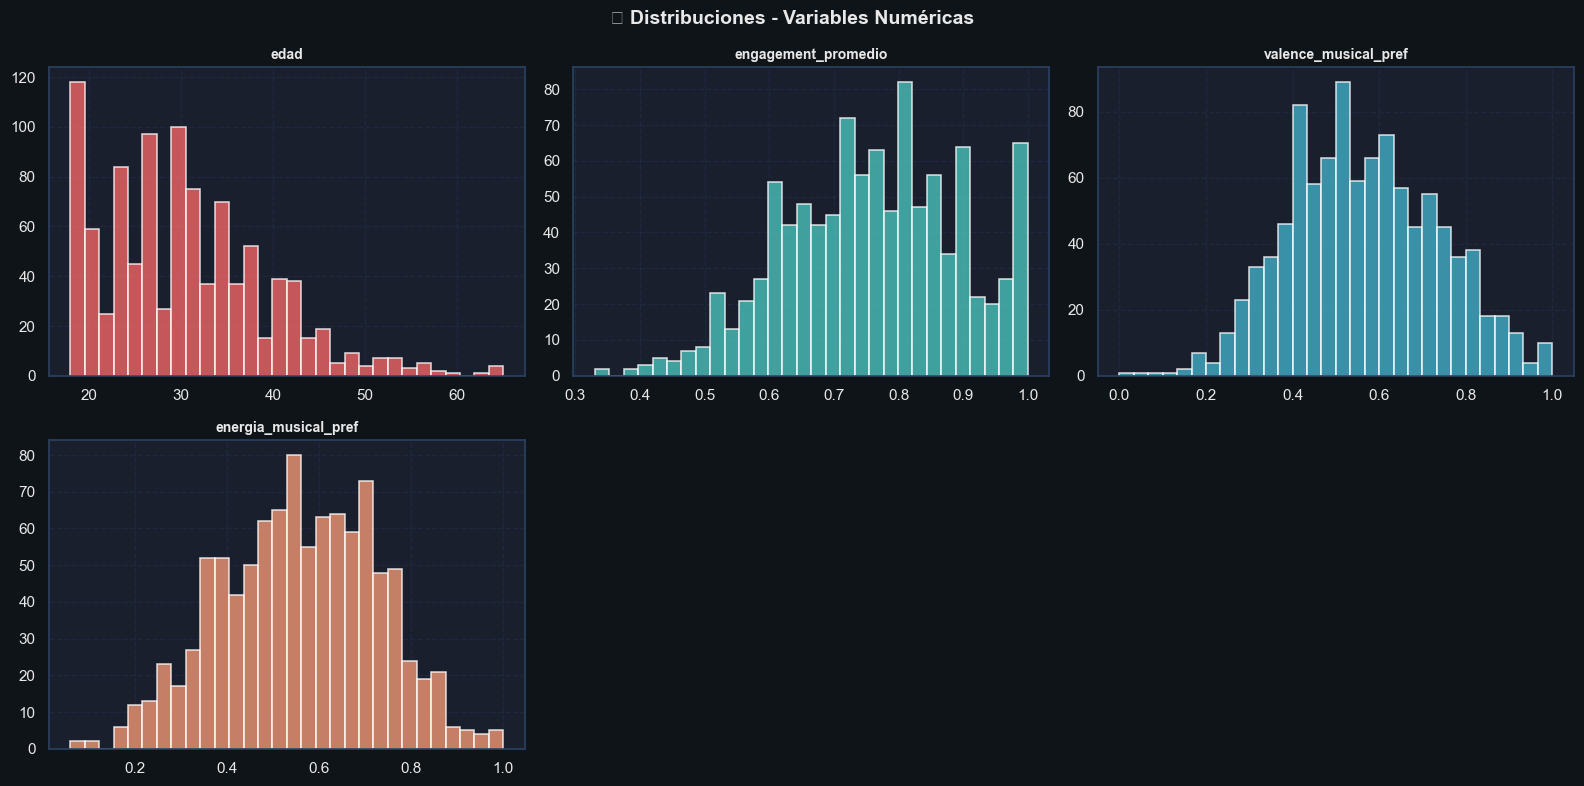

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(numeric_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()
fig.suptitle(" Distribuciones - Variables Numéricas", fontsize=14, fontweight="bold")

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    ax.hist(df[col].dropna(), bins=30, color=PALETTE[idx % 6], alpha=0.75, edgecolor="white", linewidth=1.2)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3, linestyle='--')

for idx in range(n, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

##  Distribuciones - Variables Categóricas

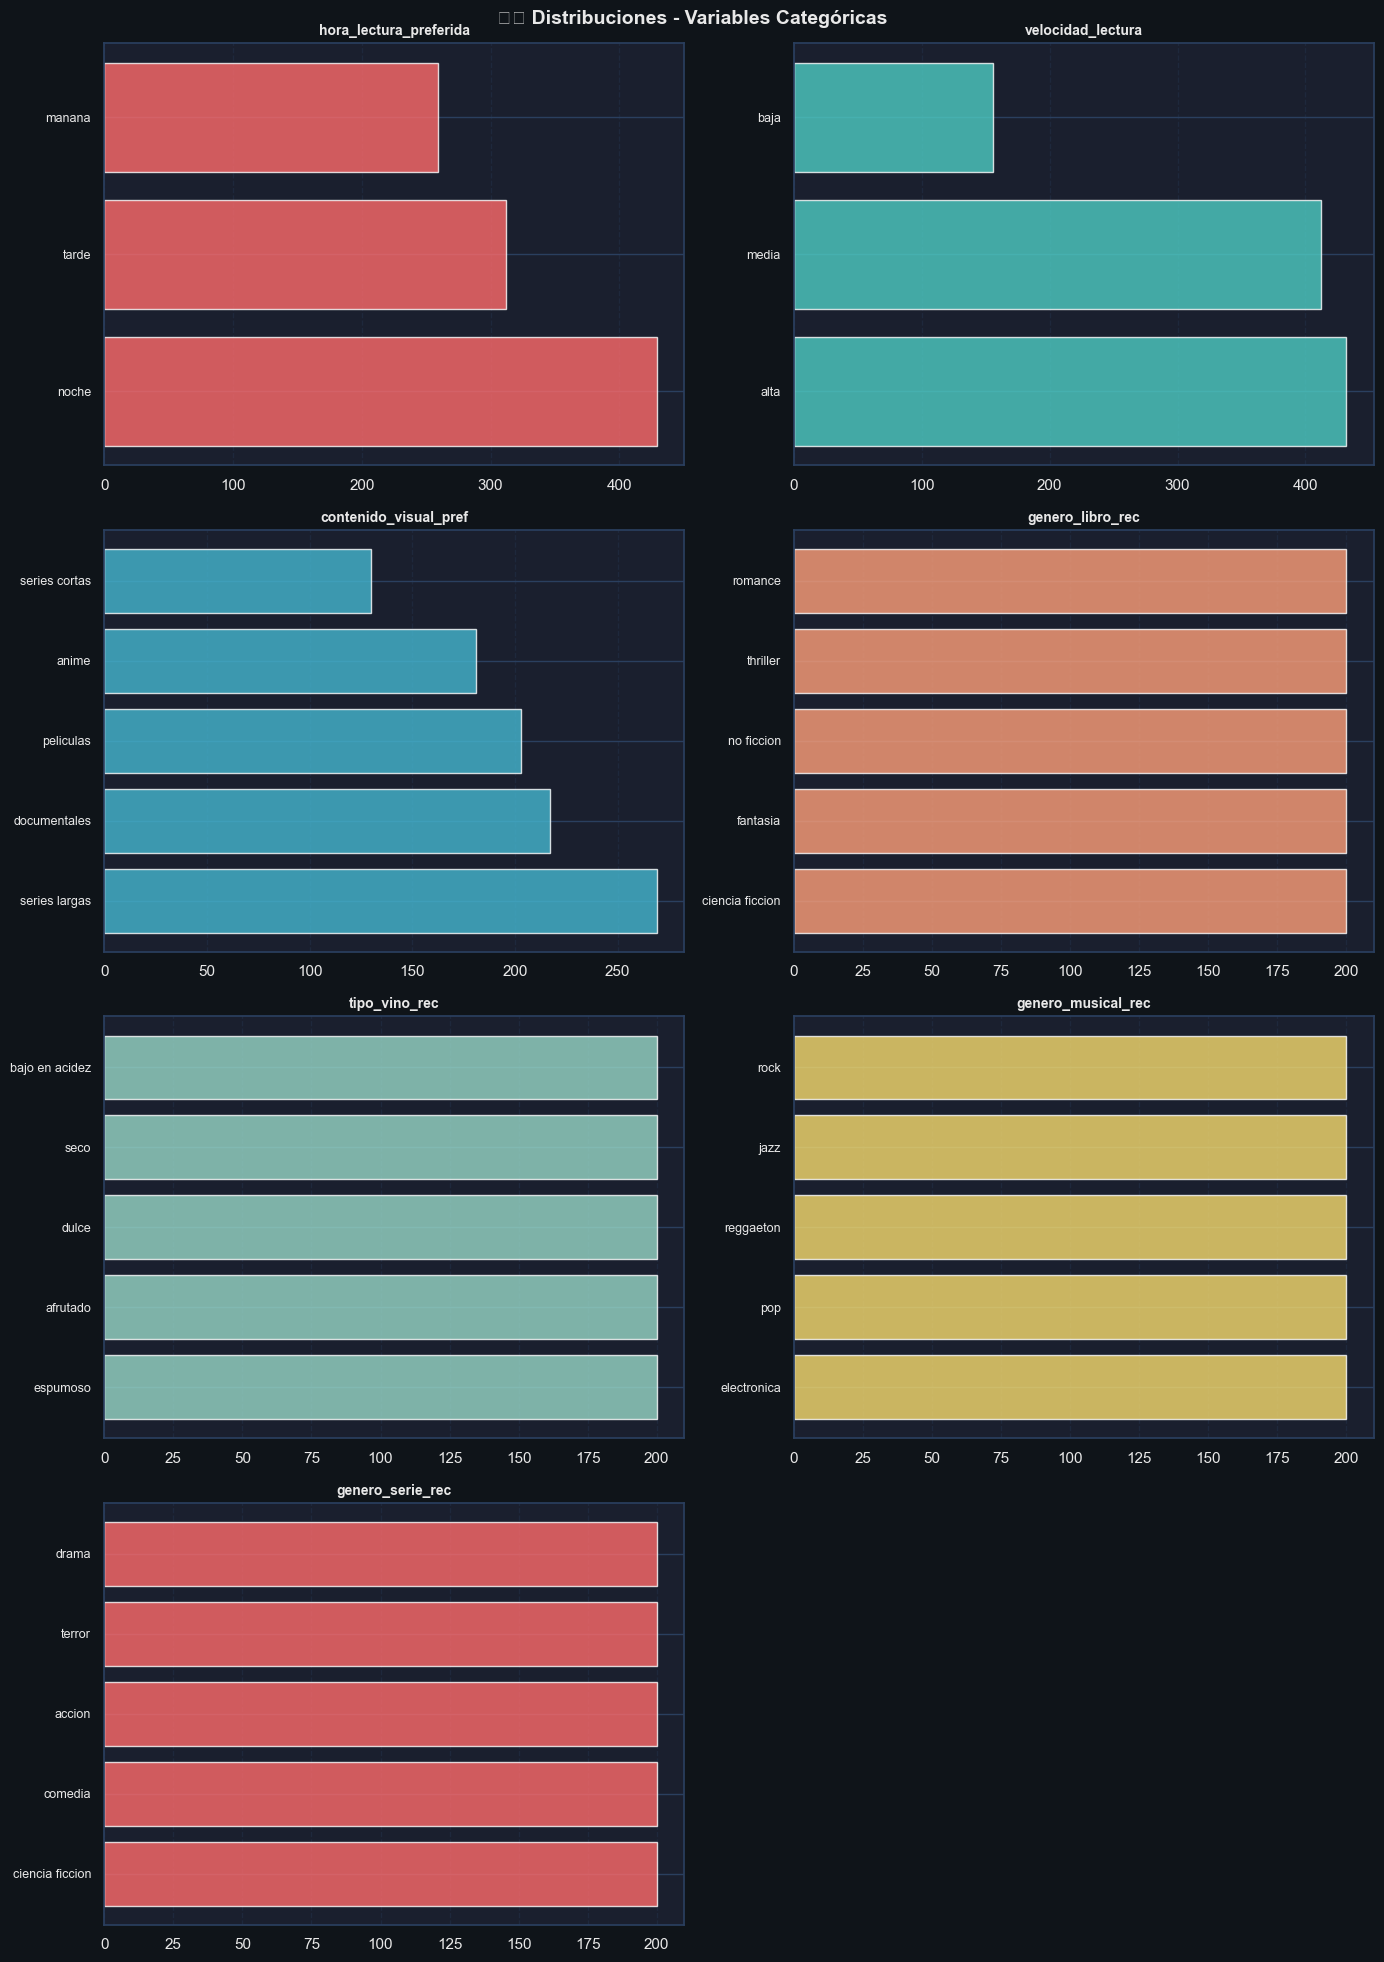

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
    n = len(categorical_cols)
    cols = 2
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5*rows))
    axes = axes.flatten()
    fig.suptitle(" Distribuciones - Variables Categóricas", fontsize=14, fontweight="bold")
    
    for idx, col in enumerate(categorical_cols):
        ax = axes[idx]
        counts = df[col].value_counts()
        ax.barh(range(len(counts)), counts.values, color=PALETTE[idx % 6], alpha=0.8, edgecolor="white", linewidth=1)
        ax.set_yticks(range(len(counts)))
        ax.set_yticklabels(counts.index, fontsize=9)
        ax.set_title(col, fontsize=10, fontweight="bold")
        ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    for idx in range(n, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables categóricas")

##  Matriz de Correlación

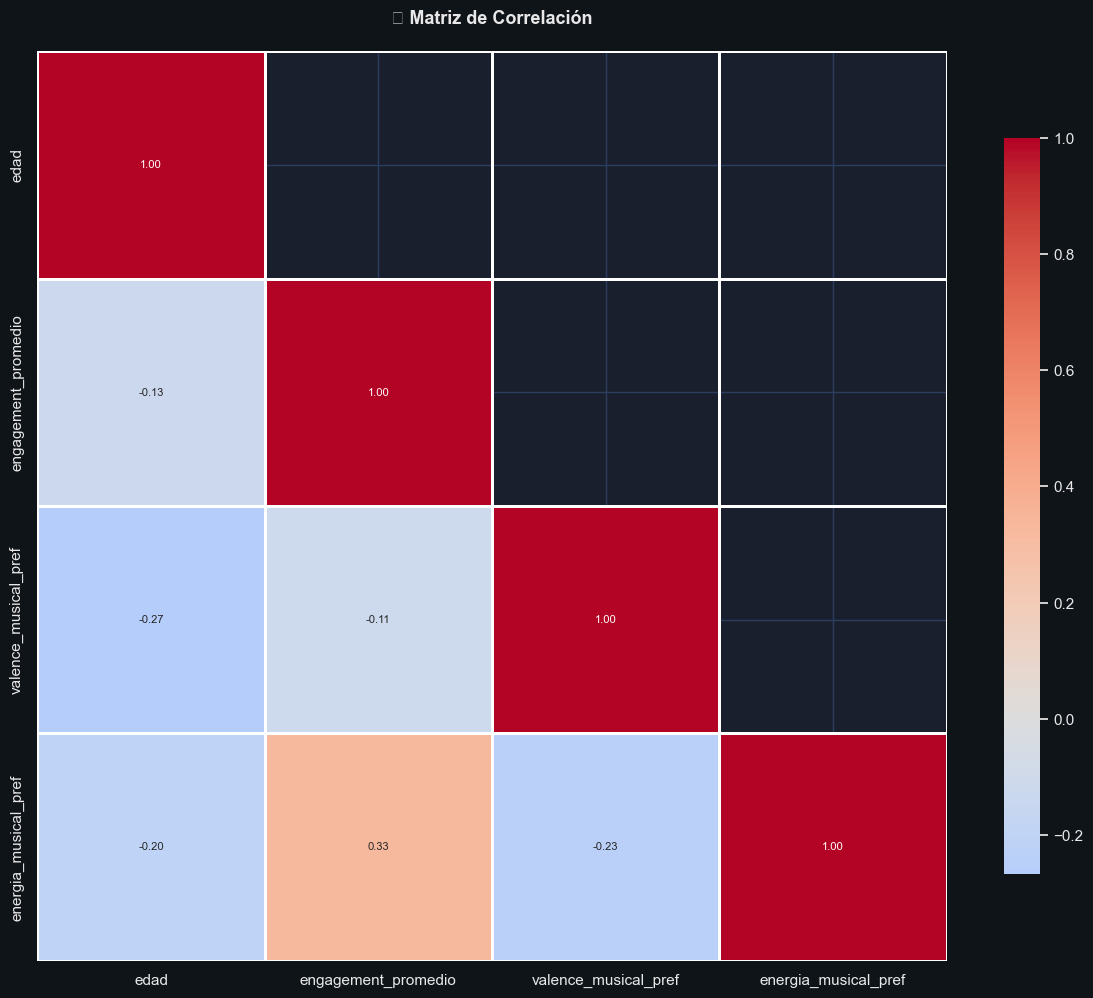

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 0:
    corr = numeric_df.corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                mask=mask, ax=ax, annot_kws={"fontsize": 8})
    
    ax.set_title(" Matriz de Correlación", fontsize=13, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables numéricas para correlación")

##  Distribuciones de Targets (Recomendadores)

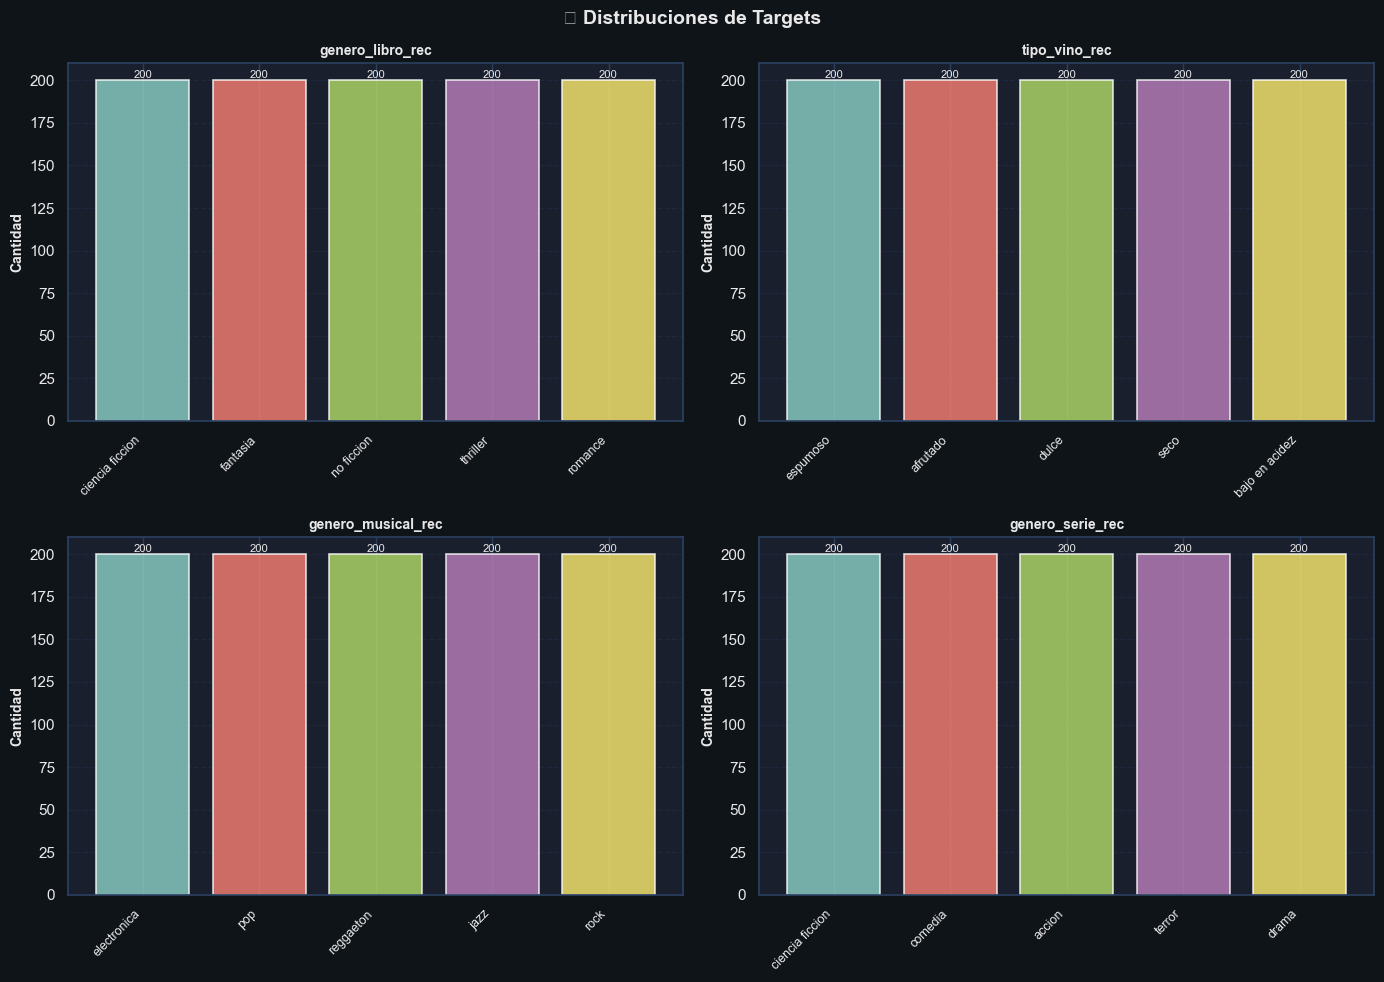

In [7]:
target_cols = [col for col in df.columns if 'rec' in col.lower()]

if target_cols:
    n = len(target_cols)
    cols = 2
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5*rows))
    axes = axes.flatten()
    fig.suptitle("🎯 Distribuciones de Targets", fontsize=14, fontweight="bold")
    
    for idx, col in enumerate(target_cols):
        ax = axes[idx]
        counts = df[col].value_counts()
        colors = plt.cm.Set3(np.linspace(0, 1, len(counts)))
        ax.bar(range(len(counts)), counts.values, color=colors, alpha=0.8, edgecolor="white", linewidth=1.2)
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel("Cantidad", fontsize=10, fontweight="bold")
        ax.set_title(col, fontsize=10, fontweight="bold")
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar in ax.patches:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    for idx in range(n, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas de targets encontradas")

##  Valores Faltantes

In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Porcentaje': missing_percent
}).sort_values('Faltantes', ascending=False)

missing_df = missing_df[missing_df['Faltantes'] > 0]

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(missing_df)))
    ax.barh(missing_df.index, missing_df['Porcentaje'], color=colors, edgecolor="white", linewidth=1.5)
    ax.set_xlabel("Porcentaje (%)", fontsize=11, fontweight="bold")
    ax.set_title(" Valores Faltantes", fontsize=13, fontweight="bold", pad=20)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (idx, row) in enumerate(missing_df.iterrows()):
        ax.text(row['Porcentaje'] + 0.5, i, f"{row['Porcentaje']:.1f}%",
               va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print(" No hay valores faltantes")

✅ No hay valores faltantes


##  MODELOS - Carga de Resultados

In [ ]:
from pathlib import Path

# Rutas de modelos
models_info = {
    "Árbol de Decisión": "../Supervised/Árbol de Decisión/reports",
    "Regresión Logística": "../Supervised/Regresión Logística/reports"
}

targets = ["genero_libro_rec", "genero_musical_rec", "genero_serie_rec", "tipo_vino_rec"]

# Verificar disponibilidad
print(" Modelos disponibles:\n")
for model_name, base_path in models_info.items():
    path = Path(base_path)
    if path.exists():
        subdirs = list(path.glob("*/"))
        print(f"✓ {model_name}: {len(subdirs)} targets")
    else:
        print(f"✗ {model_name}: no encontrado")

🤖 Modelos disponibles:

✓ Árbol de Decisión: 4 targets
✓ Regresión Logística: 4 targets


##  Árbol de Decisión - Matrices de Confusión

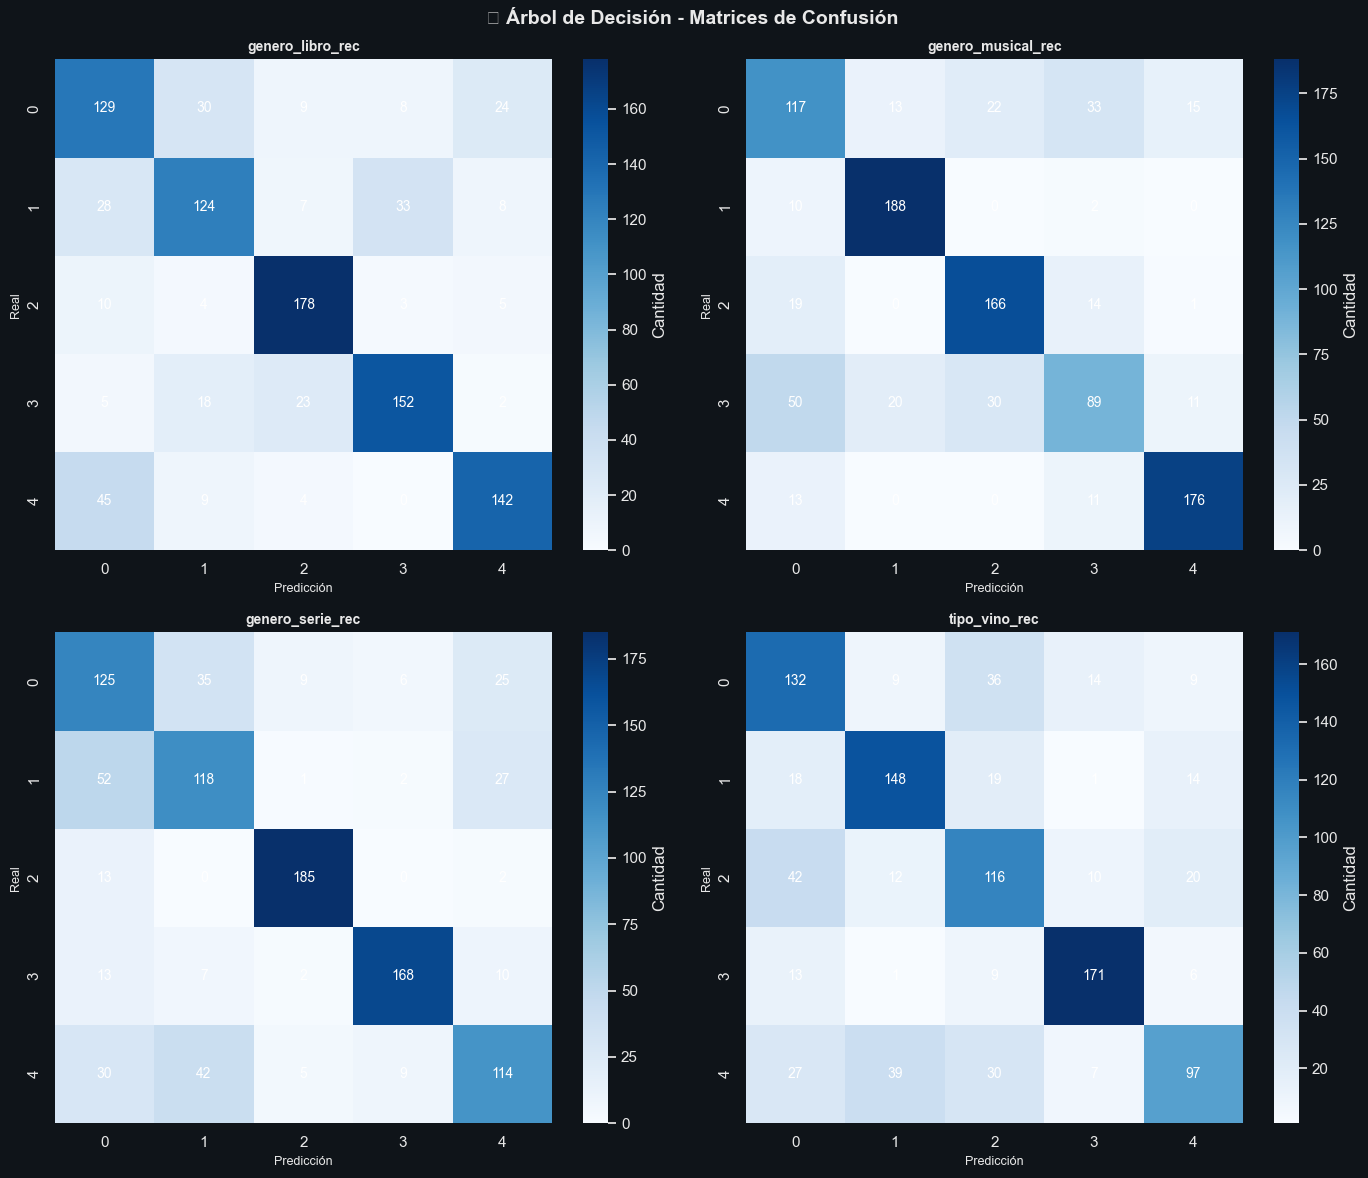

In [ ]:
base_path = "../Supervised/Árbol de Decisión/reports"

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
fig.suptitle(" Árbol de Decisión - Matrices de Confusión", fontsize=14, fontweight="bold")

for idx, target in enumerate(targets):
    ax = axes[idx]
    pred_path = f"{base_path}/{target}/predictions.csv"
    
    try:
        pred_df = pd.read_csv(pred_path)
        y_true = pred_df[target]
        y_pred = pred_df[f"pred_{target}"]
        
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    cbar_kws={'label': 'Cantidad'}, annot_kws={'fontsize': 10, 'color': 'white'})
        ax.set_title(target, fontsize=10, fontweight="bold")
        ax.set_ylabel("Real", fontsize=9)
        ax.set_xlabel("Predicción", fontsize=9)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:30]}", ha='center', va='center', fontsize=8)
        ax.set_title(target, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

##  Regresión Logística - Matrices de Confusión

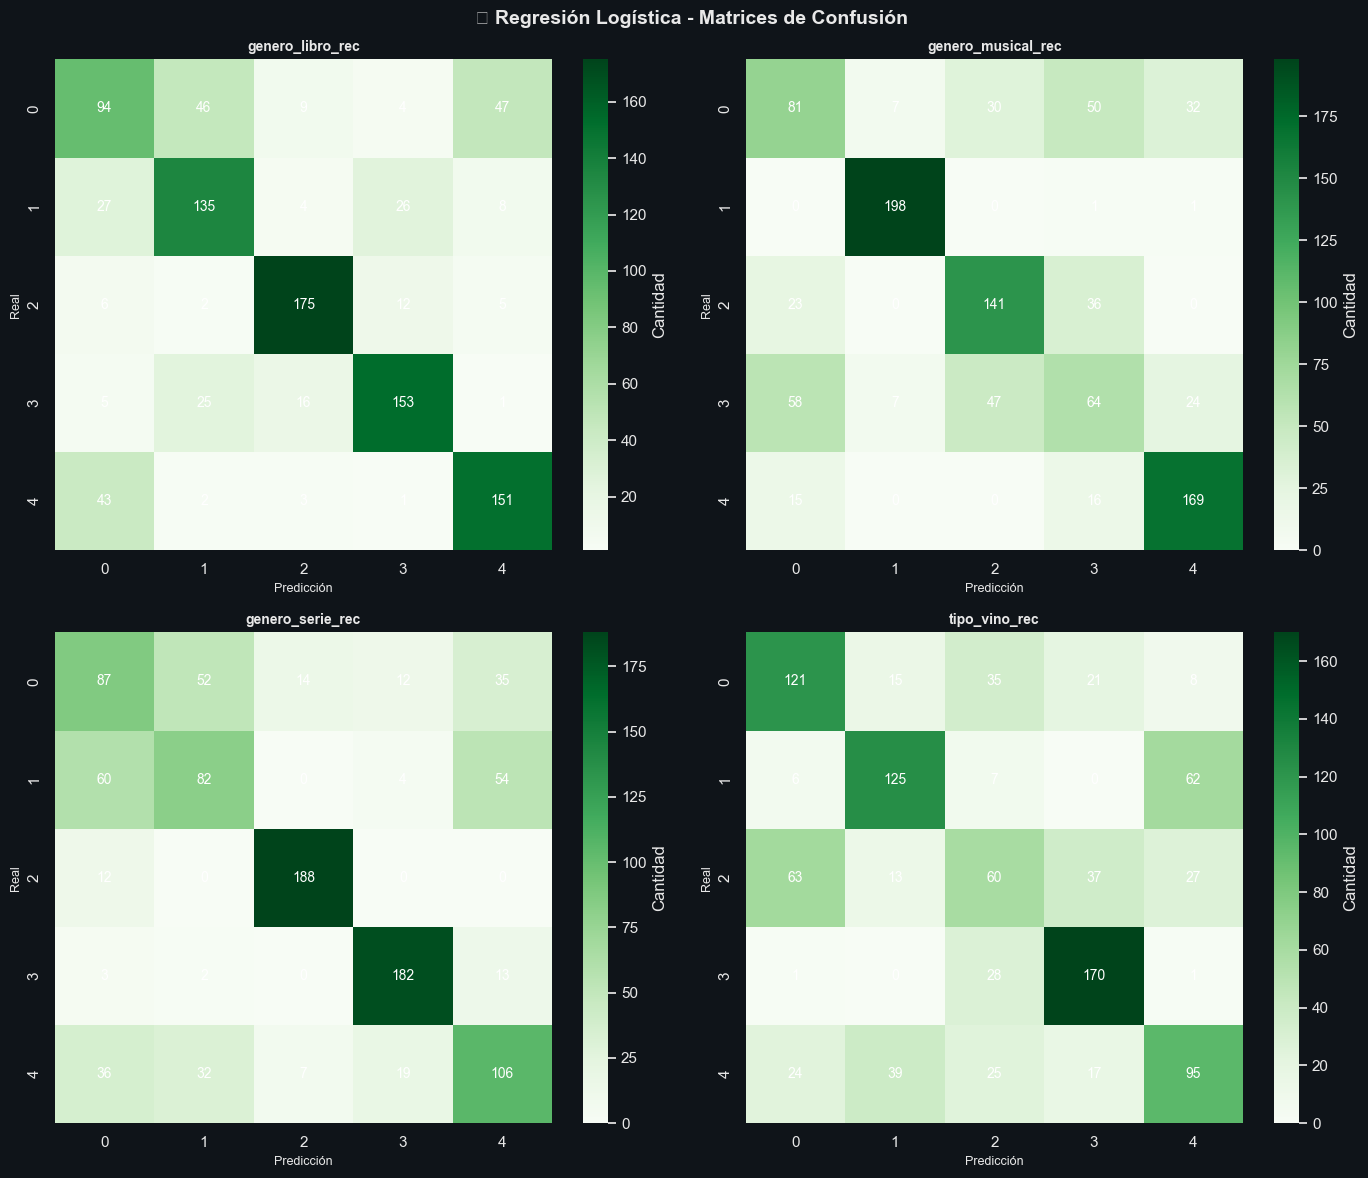

In [ ]:
base_path = "../Supervised/Regresión Logística/reports"

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
fig.suptitle("Regresión Logística - Matrices de Confusión", fontsize=14, fontweight="bold")

for idx, target in enumerate(targets):
    ax = axes[idx]
    pred_path = f"{base_path}/{target}/predictions.csv"
    
    try:
        pred_df = pd.read_csv(pred_path)
        y_true = pred_df[target]
        y_pred = pred_df[f"pred_{target}"]
        
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                    cbar_kws={'label': 'Cantidad'}, annot_kws={'fontsize': 10, 'color': 'white'})
        ax.set_title(target, fontsize=10, fontweight="bold")
        ax.set_ylabel("Real", fontsize=9)
        ax.set_xlabel("Predicción", fontsize=9)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:30]}", ha='center', va='center', fontsize=8)
        ax.set_title(target, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

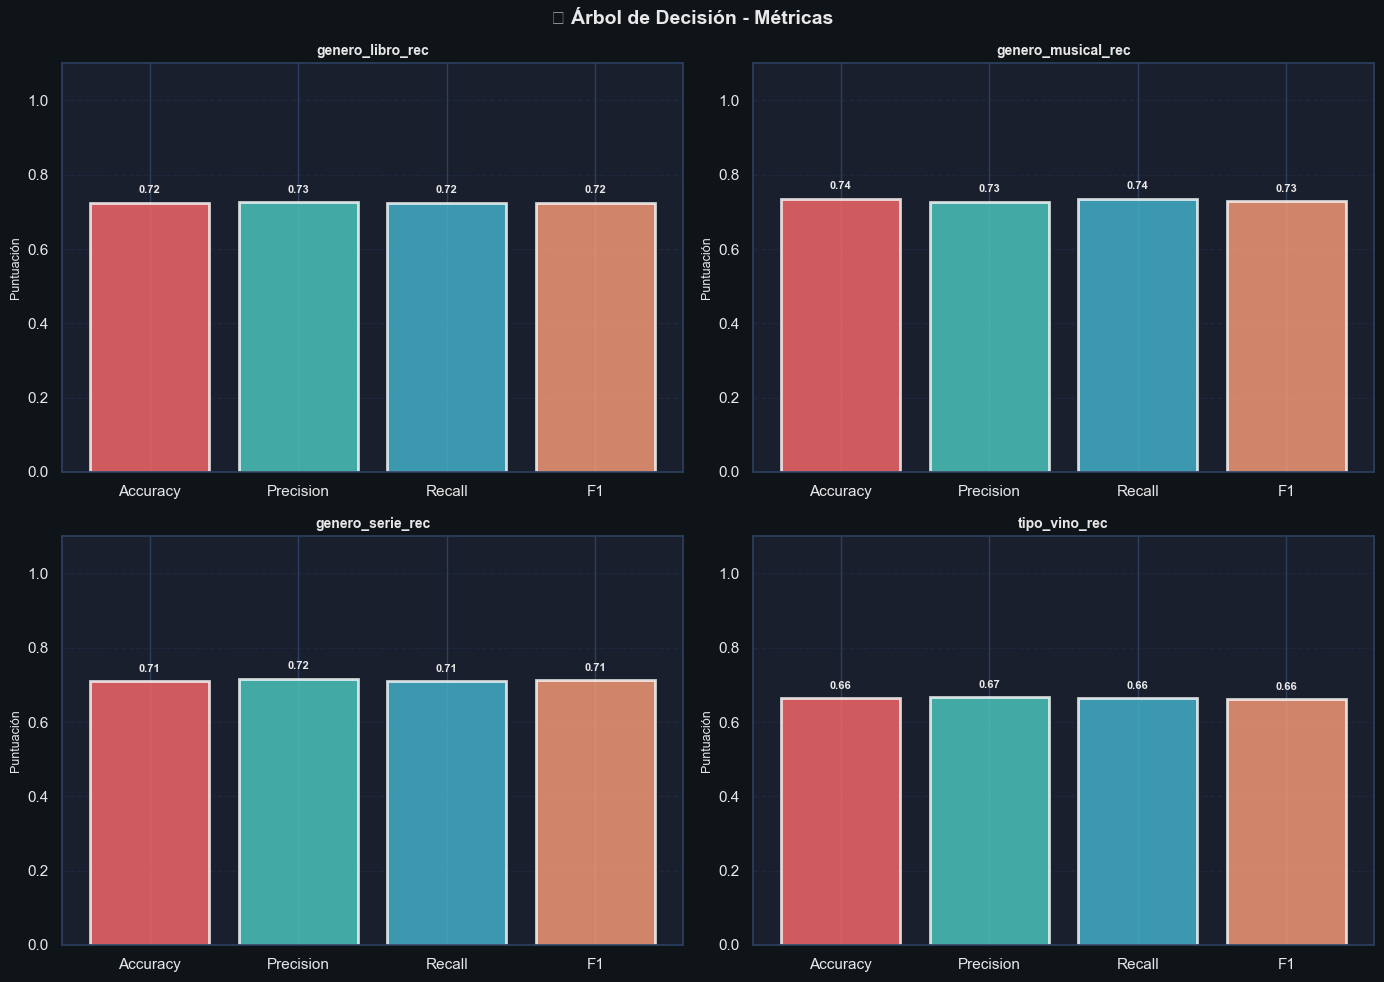

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

base_path = "../Supervised/Árbol de Decisión/reports"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle(" Árbol de Decisión - Métricas", fontsize=14, fontweight="bold")

for idx, target in enumerate(targets):
    ax = axes[idx]
    pred_path = f"{base_path}/{target}/predictions.csv"
    
    try:
        pred_df = pd.read_csv(pred_path)
        y_true = pred_df[target]
        y_pred = pred_df[f"pred_{target}"]
        
        metrics = {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0)
        }
        
        metric_names = list(metrics.keys())
        metric_values = list(metrics.values())
        colors_m = PALETTE[:len(metrics)]
        
        ax.bar(metric_names, metric_values, color=colors_m, alpha=0.8, edgecolor='white', linewidth=2)
        ax.set_ylim([0, 1.1])
        ax.set_ylabel("Puntuación", fontsize=9)
        ax.set_title(target, fontsize=10, fontweight="bold")
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar, value in zip(ax.patches, metric_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{value:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha='center', va='center', fontsize=8)
        ax.set_title(target, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

##  Métricas - Regresión Logística

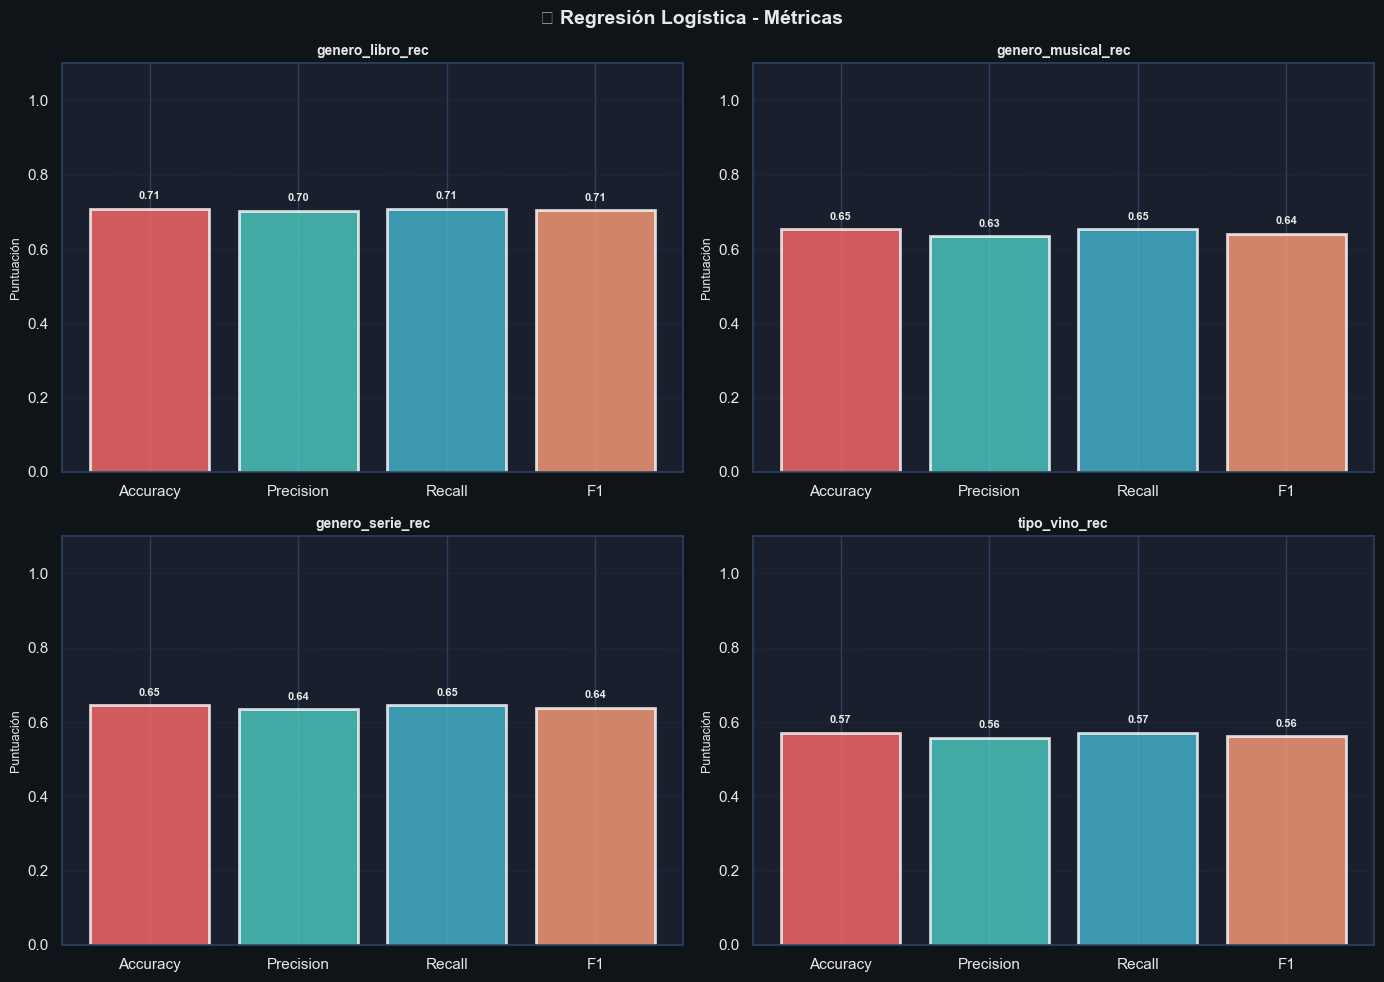

In [ ]:
base_path = "../Supervised/Regresión Logística/reports"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle(" Regresión Logística - Métricas", fontsize=14, fontweight="bold")

for idx, target in enumerate(targets):
    ax = axes[idx]
    pred_path = f"{base_path}/{target}/predictions.csv"
    
    try:
        pred_df = pd.read_csv(pred_path)
        y_true = pred_df[target]
        y_pred = pred_df[f"pred_{target}"]
        
        metrics = {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0)
        }
        
        metric_names = list(metrics.keys())
        metric_values = list(metrics.values())
        colors_m = PALETTE[:len(metrics)]
        
        ax.bar(metric_names, metric_values, color=colors_m, alpha=0.8, edgecolor='white', linewidth=2)
        ax.set_ylim([0, 1.1])
        ax.set_ylabel("Puntuación", fontsize=9)
        ax.set_title(target, fontsize=10, fontweight="bold")
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar, value in zip(ax.patches, metric_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{value:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    except Exception as e:
        ax.text(0.5, 0.5, f"Error", ha='center', va='center', fontsize=8)
        ax.set_title(target, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

##  Comparación de Modelos

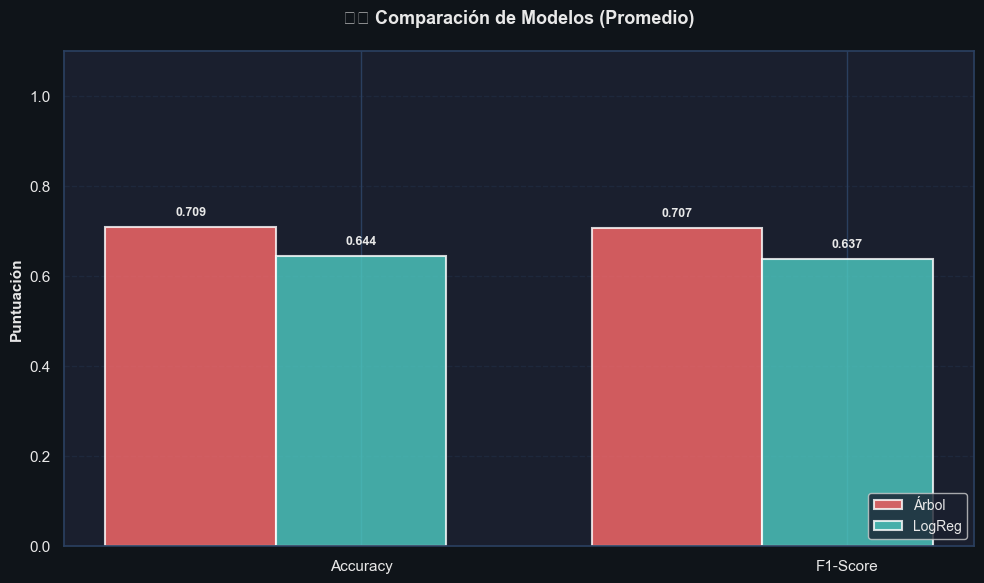


📋 Tabla Resumen:
        Accuracy  F1-Score
Árbol     0.7088    0.7068
LogReg    0.6442    0.6367


In [ ]:
models_paths = {
    "Árbol": "../Supervised/Árbol de Decisión/reports",
    "LogReg": "../Supervised/Regresión Logística/reports"
}

models_metrics = {}

for model_name, base_path in models_paths.items():
    accuracies = []
    f1s = []
    
    for target in targets:
        pred_path = f"{base_path}/{target}/predictions.csv"
        try:
            pred_df = pd.read_csv(pred_path)
            y_true = pred_df[target]
            y_pred = pred_df[f"pred_{target}"]
            
            acc = accuracy_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
            accuracies.append(acc)
            f1s.append(f1)
        except:
            pass
    
    if accuracies:
        models_metrics[model_name] = {
            'Accuracy': np.mean(accuracies),
            'F1-Score': np.mean(f1s)
        }

if models_metrics:
    df_comp = pd.DataFrame(models_metrics).T
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(df_comp.columns))
    width = 0.35
    
    for i, model in enumerate(df_comp.index):
        offset = (i - len(df_comp) / 2) * width
        values = df_comp.loc[model].values
        ax.bar(x + offset, values, width, label=model, color=PALETTE[i], alpha=0.8, edgecolor='white', linewidth=1.5)
        
        for j, v in enumerate(values):
            ax.text(x[j] + offset, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel("Puntuación", fontsize=11, fontweight="bold")
    ax.set_title(" Comparación de Modelos (Promedio)", fontsize=13, fontweight="bold", pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(df_comp.columns)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])
    
    plt.tight_layout()
    plt.show()
    
    print("\n Tabla Resumen:")
    print(df_comp.round(4).to_string())
else:
    print("No hay datos disponibles para comparación")

##  Dashboard Interactivo - Exploración de Datos

In [ ]:
if len(numeric_cols) >= 2 and len(categorical_cols) > 0:
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=("Histograma", "Box Plot", "Scatter Plot", "Distribución Categórica"),
        specs=[[{"type": "histogram"}, {"type": "box"}],
               [{"type": "scatter"}, {"type": "bar"}]]
    )
    
    # Histograma
    fig.add_trace(
        go.Histogram(x=df[numeric_cols[0]], name="Distribución", 
                    marker_color=PALETTE[0], nbinsx=30),
        row=1, col=1
    )
    
    # Box Plot
    if len(numeric_cols) > 1:
        fig.add_trace(
            go.Box(y=df[numeric_cols[1]], name="Box Plot",
                  marker_color=PALETTE[1]),
            row=1, col=2
        )
    
    # Scatter
    if len(numeric_cols) >= 2:
        fig.add_trace(
            go.Scatter(x=df[numeric_cols[0]], y=df[numeric_cols[1]],
                      mode='markers', name="Scatter",
                      marker=dict(color=PALETTE[2], size=5)),
            row=2, col=1
        )
    
    # Categorías
    if categorical_cols:
        counts = df[categorical_cols[0]].value_counts()
        fig.add_trace(
            go.Bar(x=counts.index, y=counts.values, name="Conteos",
                  marker_color=PALETTE[3]),
            row=2, col=2
        )
    
    fig.update_layout(
        height=1000,
        width=1200,
        showlegend=False,
        paper_bgcolor="#0F1419",
        plot_bgcolor="#1a1f2e",
        font=dict(color="#E8E8E8"),
        title_text=" Dashboard Interactivo - Exploración de Datos",
    )
    
    fig.show()
else:
    print("Datos insuficientes para dashboard")

##  Análisis de Clustering (No Supervisado)

In [ ]:
import sys
sys.path.append("../unsupervised")

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Intenta cargar datos de clustering si existen
try:
    from clustering import (
        RUTA_CSV, COLUMNAS_DOMINIO, N_CLUSTERS, RANDOM_STATE, N_INIT
    )
    from sklearn.cluster import KMeans
    
    # Carga dataset y realiza clustering
    df_cluster = pd.read_csv(RUTA_CSV)
    
    # Define features
    features_cols = [
        "edad", "engagement_promedio", "valence_musical_pref", "energia_musical_pref",
        "hora_lectura_preferida_manana", "hora_lectura_preferida_noche", "hora_lectura_preferida_tarde",
        "velocidad_lectura_alta", "velocidad_lectura_baja", "velocidad_lectura_media",
        "contenido_visual_pref_anime", "contenido_visual_pref_documentales",
        "contenido_visual_pref_peliculas", "contenido_visual_pref_series cortas",
        "contenido_visual_pref_series largas"
    ]
    
    # Filtra features existentes
    features_disponibles = [f for f in features_cols if f in df_cluster.columns]
    X_cluster = df_cluster[features_disponibles].fillna(0)
    
    # Realiza KMeans
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=N_INIT)
    clusters = kmeans.fit_predict(X_cluster)
    
    print(f"   Clustering cargado exitosamente")
    print(f"   Muestras: {len(clusters)}")
    print(f"   Clusters: {len(np.unique(clusters))}")
    print(f"   Silhouette Score: {silhouette_score(X_cluster, clusters):.4f}")
except Exception as e:
    print(f"  No se pudo cargar clustering: {str(e)}")

✅ Clustering cargado exitosamente
   Muestras: 1000
   Clusters: 5
   Silhouette Score: 0.1197


Calculando t-SNE... (esto puede tomar unos segundos)


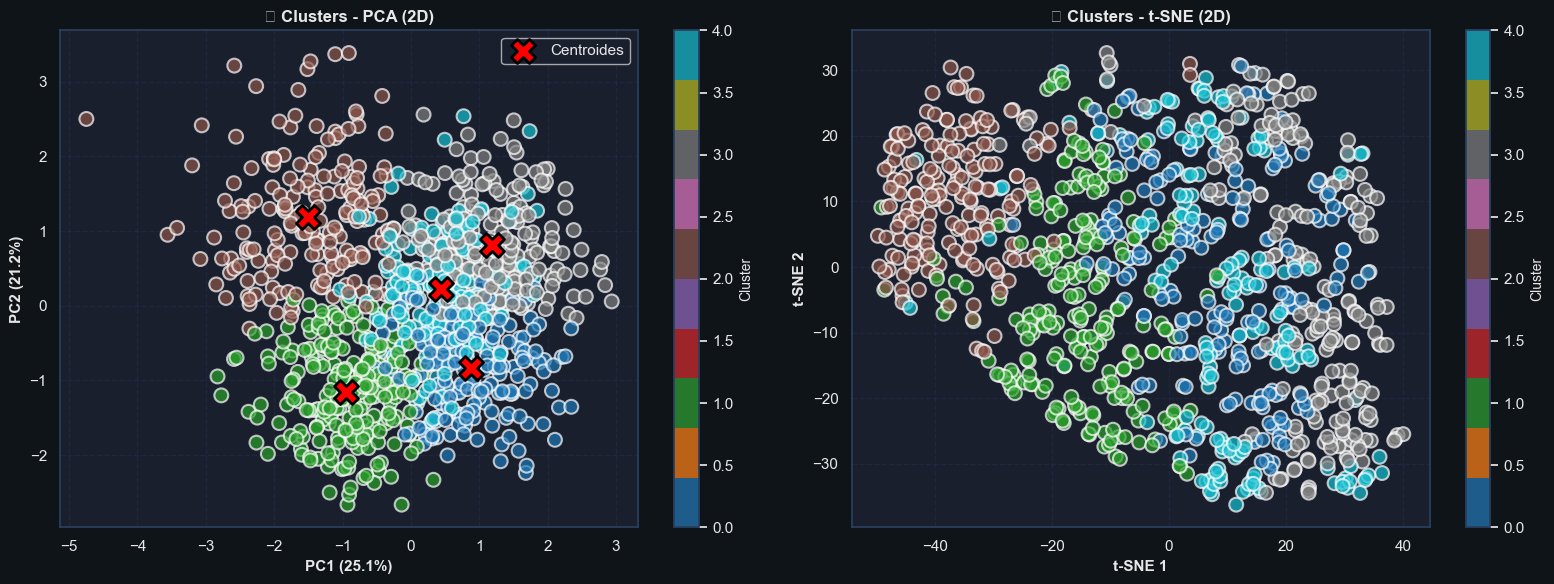

In [ ]:
if 'clusters' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # PCA Visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_cluster)
    
    scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', 
                               s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
    axes[0].scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
                   pca.transform(kmeans.cluster_centers_)[:, 1],
                   c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroides')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
    axes[0].set_title('🔵 Clusters - PCA (2D)', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3, linestyle='--')
    axes[0].legend()
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Cluster', fontsize=10)
    
    # t-SNE Visualization
    print("Calculando t-SNE... (esto puede tomar unos segundos)")
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
    X_tsne = tsne.fit_transform(X_cluster)
    
    scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='tab10',
                               s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
    axes[1].set_xlabel('t-SNE 1', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('t-SNE 2', fontsize=11, fontweight='bold')
    axes[1].set_title('🔵 Clusters - t-SNE (2D)', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, linestyle='--')
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label('Cluster', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("  No hay datos de clustering disponibles")

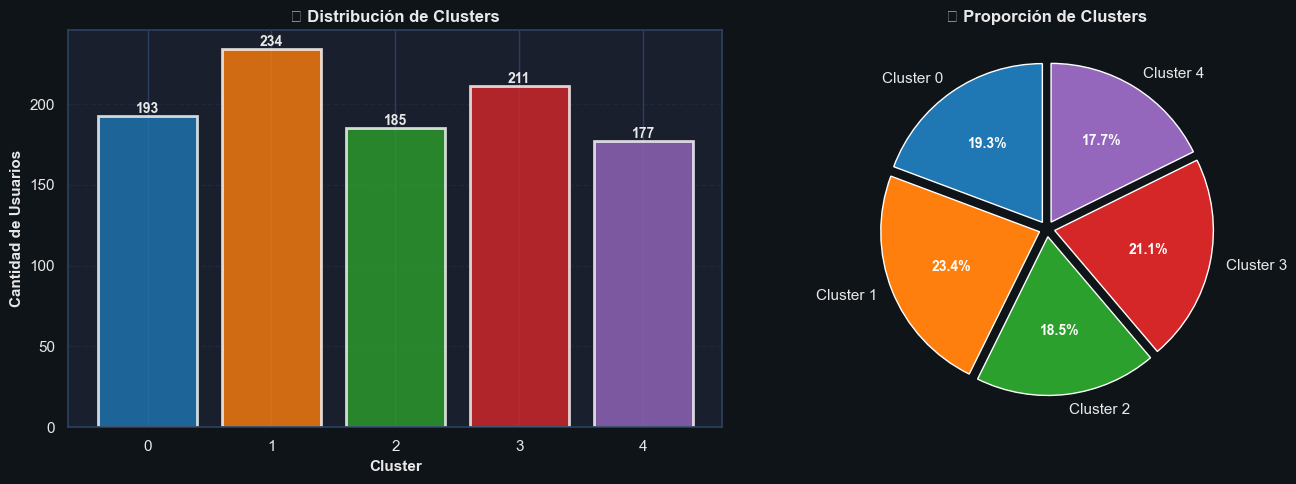

In [ ]:
if 'clusters' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Conteo de clusters
    unique_clusters, counts = np.unique(clusters, return_counts=True)
    colors_clusters = plt.cm.tab10(unique_clusters)
    
    bars = axes[0].bar(unique_clusters, counts, color=colors_clusters, alpha=0.8, edgecolor='white', linewidth=2)
    axes[0].set_xlabel('Cluster', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Cantidad de Usuarios', fontsize=11, fontweight='bold')
    axes[0].set_title(' Distribución de Clusters', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(count)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Distribución porcentual (pie chart)
    colors_pie = [plt.cm.tab10(i) for i in unique_clusters]
    wedges, texts, autotexts = axes[1].pie(counts, labels=[f'Cluster {i}' for i in unique_clusters],
                                             autopct='%1.1f%%', colors=colors_pie, startangle=90,
                                             explode=[0.05]*len(unique_clusters))
    axes[1].set_title('🥧 Proporción de Clusters', fontsize=12, fontweight='bold')
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    plt.tight_layout()
    plt.show()
else:
    print("  No hay datos de clustering disponibles")

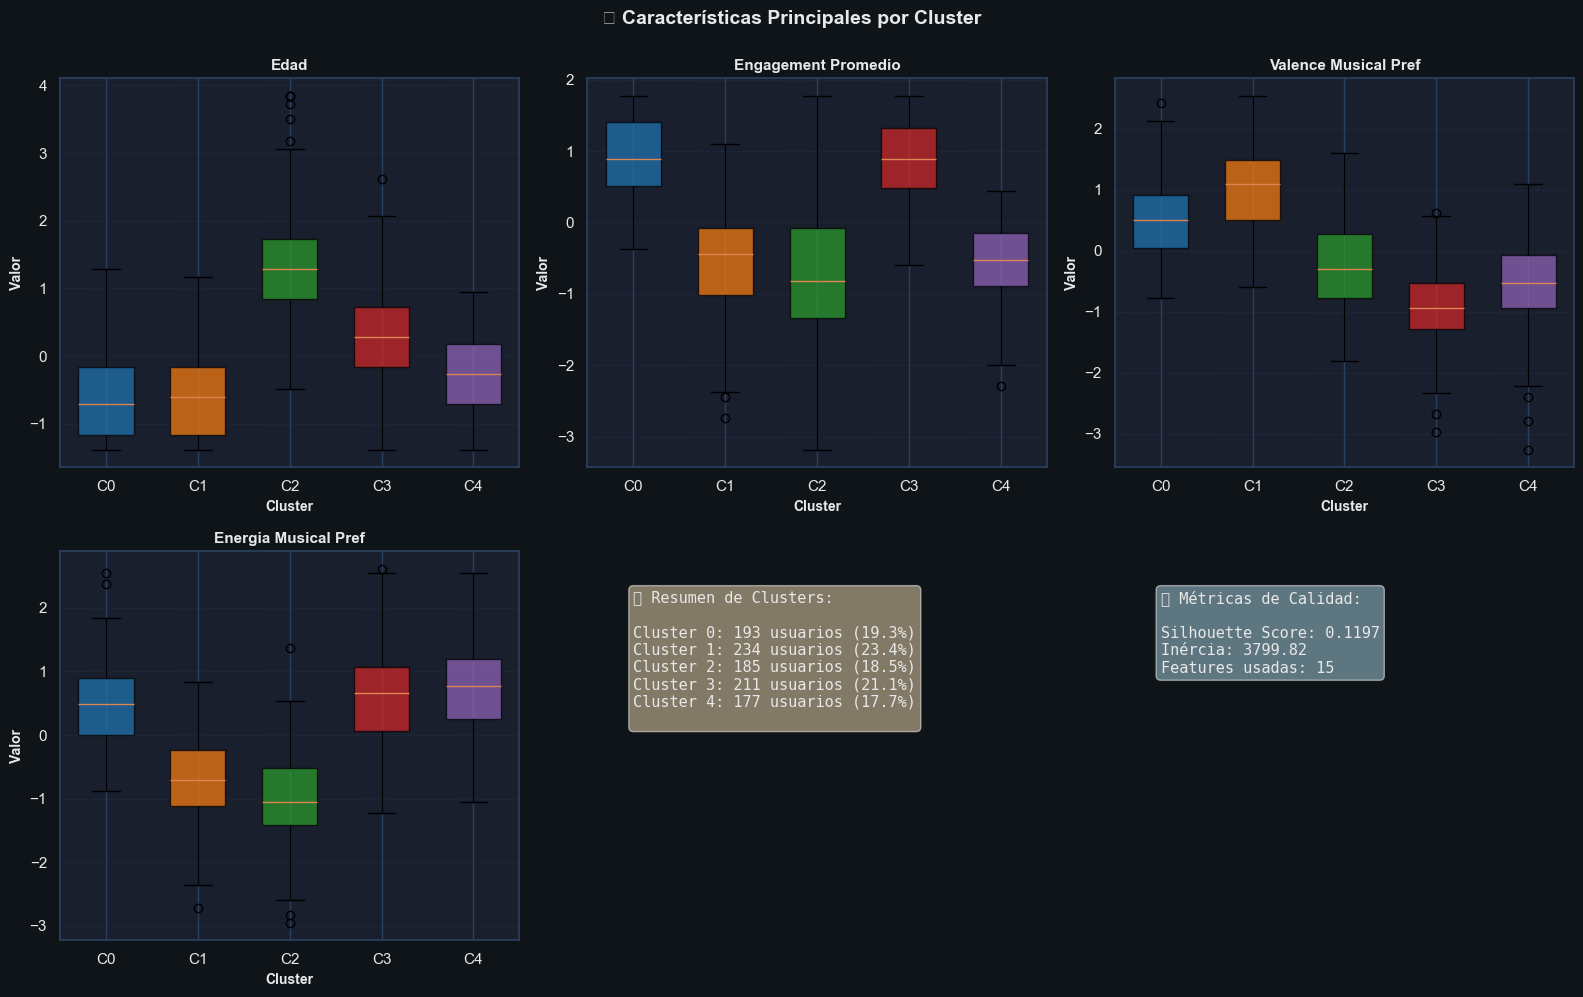

In [ ]:
if 'clusters' in locals():
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    fig.suptitle(' Características Principales por Cluster', fontsize=14, fontweight='bold', y=0.995)
    
    # Selecciona las features numéricas más importantes
    numeric_features = ['edad', 'engagement_promedio', 'valence_musical_pref', 
                       'energia_musical_pref']
    
    for idx, feature in enumerate(numeric_features):
        if feature in X_cluster.columns:
            ax = axes[idx]
            feature_data = [X_cluster.iloc[clusters == i, X_cluster.columns.get_loc(feature)].values 
                           for i in range(N_CLUSTERS)]
            
            bp = ax.boxplot(feature_data, labels=[f'C{i}' for i in range(N_CLUSTERS)],
                           patch_artist=True, widths=0.6)
            
            for patch, color in zip(bp['boxes'], plt.cm.tab10(range(N_CLUSTERS))):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            ax.set_ylabel('Valor', fontsize=10, fontweight='bold')
            ax.set_xlabel('Cluster', fontsize=10, fontweight='bold')
            ax.set_title(feature.replace('_', ' ').title(), fontsize=11, fontweight='bold')
            ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Estadísticas generales por cluster
    ax = axes[-2]
    ax.axis('off')
    stats_text = " Resumen de Clusters:\n\n"
    for i in range(N_CLUSTERS):
        count = np.sum(clusters == i)
        pct = (count / len(clusters)) * 100
        stats_text += f"Cluster {i}: {count} usuarios ({pct:.1f}%)\n"
    ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=11,
           verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Inércia y silhouette
    ax = axes[-1]
    ax.axis('off')
    sil_score = silhouette_score(X_cluster, clusters)
    inertia = kmeans.inertia_
    info_text = f" Métricas de Calidad:\n\n"
    info_text += f"Silhouette Score: {sil_score:.4f}\n"
    info_text += f"Inércia: {inertia:.2f}\n"
    info_text += f"Features usadas: {len(features_disponibles)}"
    ax.text(0.1, 0.9, info_text, transform=ax.transAxes, fontsize=11,
           verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
else:
    print("  No hay datos de clustering disponibles")